# MNIST


Este notebook demonstra um **Perceptron Multicamadas (MLP)** simples implementado usando PyTorch para classificar dígitos manuscritos do **conjunto de dados MNIST**.

Abordaremos as seguintes etapas:
1.  **Carregamento e Pré-processamento de Dados**: Carregar o conjunto de dados MNIST, binarizar os valores dos pixels e convertê-los em tensores PyTorch.
2.  **Reprodutibilidade**: Definir seeds aleatórias para resultados consistentes.
3.  **Exploração de Dados**: Entender a forma dos nossos dados e visualizar um dígito de exemplo.
4.  **Remodelagem de Dados**: Preparar os dados da imagem para a camada de entrada da rede neural.
5.  **Definição do Modelo**: Projetar uma arquitetura de rede neural simples usando `torch.nn`.
6.  **Treinamento**: Implementar um loop de treinamento com mini-batches, um otimizador e uma função de perda.
7.  **Inferência**: Usar o modelo treinado para fazer previsões em novos dados.
8.  **Salvamento do Modelo**: Armazenar os pesos do modelo treinado para uso futuro.

### 1. Carregamento e Pré-processamento de Dados

Primeiro, carregamos as bibliotecas necessárias e o conjunto de dados MNIST. Em seguida, pré-processamos as imagens binarizando os valores dos pixels (convertendo-os para 0 ou 1) e transformando-os em tensores PyTorch, que são as estruturas de dados padrão para operações PyTorch.

In [68]:
# Bibliotecas

import numpy as np
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [84]:
# Dados

# Carrega o conjunto de dados MNIST do TensorFlow Keras. Este conjunto de dados consiste em 60.000 exemplos de treinamento
# e 10.000 exemplos de teste de dígitos manuscritos (0-9).
from tensorflow.keras.datasets import mnist    # Importando o DataSet do TensorFlow

# Carrega e pré-processa os dados MNIST
# x_train, y_train são imagens e rótulos para treinamento
# x_test, y_test são imagens e rótulos para teste
(x_train, y_train), (x_test, y_test) = mnist.load_data()     # Temos o Split de Treino e Teste.

# Binarizando os valores dos pixels: pixels com intensidade > 127 se tornam 1.0, caso contrário 0.0.
# Isso simplifica os dados da imagem, tratando cada pixel como 'ligado' ou 'desligado'.
x_train = (x_train > 127).astype('float32')
x_test = (x_test > 127).astype('float32') # Variável corrigida de X_test para x_test para consistência

# Converte arrays NumPy para tensores PyTorch.
# x_train e x_test contêm os dados da imagem.
# y_train e y_test contêm os rótulos correspondentes (o dígito que cada imagem representa).
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.LongTensor(y_train) # Rótulos são tipicamente LongTensor para tarefas de classificação
y_test = torch.LongTensor(y_test)   # Rótulos são tipicamente LongTensor para tarefas de classificação

### 2. Definindo Seeds Aleatórias para Reprodutibilidade

Para garantir que nossos resultados sejam reproduzíveis (ou seja, obtenhamos o mesmo resultado toda vez que executarmos o notebook), é crucial definir seeds aleatórias para todas as bibliotecas que usam geração de números aleatórios, como `random`, `numpy` e `torch`.

In [70]:
# Usamos Random para inicializar nossos pesos, então precisamos setar a seed para reprodutibilidade

seed = 124

# Módulo random embutido do Python
random.seed(seed)

# Gerador de números aleatórios global do NumPy
np.random.seed(seed)

# API de Gerador recomendada do NumPy (mais robusta para aplicações complexas)
numpy_generator = np.random.default_rng(seed)

# Geradores de números aleatórios globais do PyTorch para CPU e CUDA (GPU)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed) # Para todas as GPUs, se houver múltiplas

# Gerador PyTorch independente (útil para operações específicas que precisam de seu próprio RNG)
torch_generator = torch.Generator()
torch_generator.manual_seed(seed)

### 3. Exploração de Dados

Antes de construir nosso modelo, vamos dar uma olhada na forma dos nossos dados e visualizar uma das imagens para entender com o que estamos trabalhando.

Formato dos dados de treinamento (imagens): torch.Size([60000, 28, 28])
Formato dos dados de treinamento (rótulos): torch.Size([60000])
Formato dos dados de teste (imagens): torch.Size([10000, 28, 28])
Formato dos dados de teste (rótulos): torch.Size([10000])


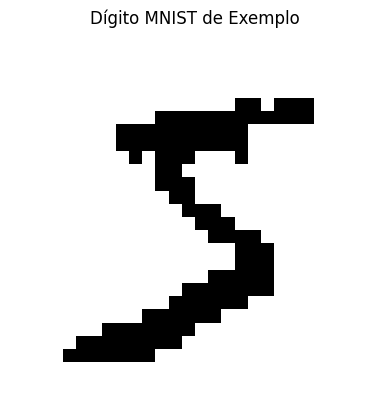

Temos 60000 exemplos de treinamento.
O rótulo para a imagem exibida é: 5


In [71]:
print(f"Formato dos dados de treinamento (imagens): {x_train.shape}") # 60.000 imagens, cada uma 28x28 pixels
print(f"Formato dos dados de treinamento (rótulos): {y_train.shape}") # 60.000 rótulos
print(f"Formato dos dados de teste (imagens): {x_test.shape}")      # 10.000 imagens, cada uma 28x28 pixels
print(f"Formato dos dados de teste (rótulos): {y_test.shape}")      # 10.000 rótulos

# Visualiza a primeira imagem de treinamento usando um mapa de cores binário (preto e branco).
# 'plt.axis('off')' remove os eixos para uma visualização mais limpa.
plt.imshow(x_train[0], cmap='binary')    # Visualizando a primeira "imagem"
plt.title("Dígito MNIST de Exemplo")
plt.axis('off')
plt.show()

print(f"Temos {len(x_train)} exemplos de treinamento.")
print(f"O rótulo para a imagem exibida é: {y_train[0].item()}") # Exibe o rótulo real

### 4. Remodelagem de Dados

A primeira camada da nossa rede neural espera um vetor 1D como entrada, não uma imagem 2D. Portanto, precisamos achatar cada imagem de 28x28 pixels em um vetor de 784 elementos (28 * 28).

In [72]:
# Mudar o grid de 28x28 para 784x1 para ser digerido pela primeira camada... Linearizando
# .view(-1, 28*28) remodela o tensor. -1 infere automaticamente o tamanho do batch.
x_train = x_train.view(-1, 28*28)
x_test = x_test.view(-1, 28*28)

#---------------------------------------------------------------
print(f"Formato dos dados de treinamento remodelados: {x_train.shape}")
print(f"Formato dos dados de teste remodelados: {x_test.shape}") # Variável corrigida de X_test para x_test para consistência

Formato dos dados de treinamento remodelados: torch.Size([60000, 784])
Formato dos dados de teste remodelados: torch.Size([10000, 784])


### 5. Definição do Modelo: Rede Neural Simples (MLP)

Definimos uma rede neural simples com duas camadas lineares e uma função de ativação ReLU. A rede receberá a imagem achatada de 784 pixels como entrada e produzirá probabilidades para cada uma das 10 classes de dígitos (0-9).

-   `nn.Linear(input_features, output_features)`: Uma transformação linear aplicada aos dados de entrada.
-   `nn.ReLU()`: Função de ativação Rectified Linear Unit, que introduz não linearidade.
-   `torch.softmax()`: Converte as pontuações brutas de saída (logits) em probabilidades que somam 1.
-   `nn.MSELoss()`: Mean Squared Error Loss (Perda de Erro Quadrático Médio), usada aqui para calcular a diferença entre as probabilidades previstas e os rótulos verdadeiros codificados em one-hot.
-   `torch.nn.functional.one_hot()`: Converte rótulos inteiros em um vetor codificado em one-hot, que é adequado para comparação com as saídas softmax.
-   `torch.argmax()`: Retorna o índice do valor máximo, usado para classificação durante a inferência.

In [73]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)  # 28*28 eh a dimencao da nossa imagem linearizada
        self.fc2 = nn.Linear(128, 10)     # (0, 1, 2, 3, 4, 5, 6, 6, 7, 8, 9) - Por tanto, a camada de output tem Dim(10)
        self.relu = nn.ReLU()


    def forward(self, x, y):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        prob = torch.softmax(x, dim=0)   # Softmax tranforma em uma distribuicao somando a 1

        criterion = nn.MSELoss()         # Usando Mean Square Error Loss, do vetor de output vs o "one-hot" label

        targets = torch.nn.functional.one_hot(y_batch, num_classes=10).float()

        loss = criterion(prob, targets)     # Calculamos a nossa Loss

        return loss   # retornamos a loss


    def __call__(self, input):
        x = self.fc1(input)
        x = self.relu(x)
        x = self.fc2(x)

        return torch.argmax(x)   # Diferentemente de softmax, armax nos da o indice do item de maior valor.
                                 # Usamos argmax na inferencia para classificacao

SimpleNN = SimpleNN()     # Inicializamos a classe do modelo! Instanciamos o modelo!

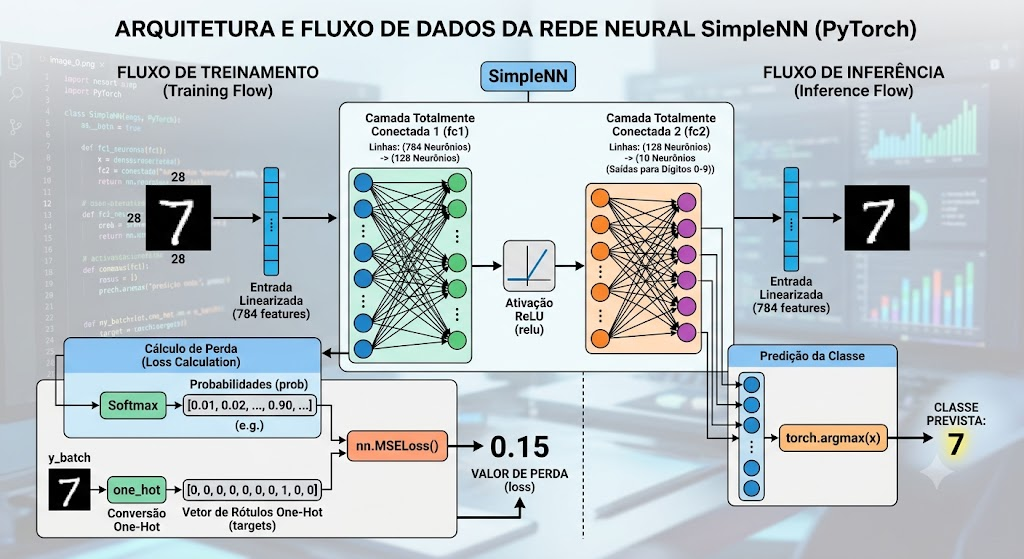

In [74]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # Primeira camada totalmente conectada: 28*28 (784) características de entrada para 128 características de saída.
        self.fc1 = nn.Linear(28*28, 128)  # 28*28 é a dimensão da nossa imagem linearizada
        # Segunda camada totalmente conectada: 128 características de entrada para 10 características de saída (para 10 classes de dígitos).
        self.fc2 = nn.Linear(128, 10)  # (0, 1, ..., 9) - portanto, a camada de saída tem Dim(10)
        # Função de ativação ReLU para introduzir não linearidade.
        self.relu = nn.ReLU()

    # O método 'forward' define como os dados fluem através da rede durante o treinamento.
    def forward(self, x, y_batch): # Renomeado 'y' para 'y_batch' para evitar confusão com o próprio parâmetro 'y' do método.
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        # Aplica softmax para converter pontuações brutas (logits) em distribuição de probabilidade.
        # 'dim=1' garante que softmax seja aplicado na dimensão da classe para cada item no batch.
        prob = torch.softmax(x, dim=1)   # Softmax transforma em uma distribuição somando a 1

        # Define a função de perda. MSELoss calcula o erro quadrático médio entre as previsões e os alvos.
        criterion = nn.MSELoss()    # Usando Mean Square Error Loss, do vetor de saída vs o rótulo "one-hot"

        # Converte os rótulos de verdade (y_batch) em vetores codificados em one-hot.
        # Isso é necessário porque MSELoss espera valores de destino contínuos, e a codificação one-hot fornece isso.
        targets = torch.nn.functional.one_hot(y_batch, num_classes=10).float()

        # Calcula a perda entre as probabilidades previstas e os alvos codificados em one-hot.
        loss = criterion(prob, targets)     # Calculamos a nossa Loss

        return loss   # Retornamos a loss

    # O método '__call__' é tipicamente usado para inferência ou quando o modelo é invocado diretamente.
    # Ele executa um forward pass e retorna a classe prevista (o índice com a maior probabilidade).
    def __call__(self, input):
        x = self.fc1(input)
        x = self.relu(x)
        x = self.fc2(x)

        # Para inferência, geralmente precisamos apenas da classe com a pontuação mais alta.
        # argmax retorna o índice do valor máximo. Este índice é o nosso dígito previsto.
        # Diferentemente de softmax, argmax nos dá o índice do item com o maior valor.
        # Usamos argmax para classificação durante a inferência.
        return torch.argmax(x)

# Inicializamos o modelo! Instanciamos o modelo!
SimpleNN = SimpleNN()

### 6. Treinamento do Modelo

Esta seção define o processo de treinamento. Iremos iterar sobre o conjunto de dados várias vezes (épocas), processar os dados em pequenos batches, calcular a perda e atualizar os pesos do modelo usando um otimizador (Stochastic Gradient Descent neste caso).

-   **Tamanho do Batch**: O número de amostras processadas antes que os parâmetros do modelo sejam atualizados.
-   **Taxa de Aprendizagem**: Determina o tamanho do passo em cada iteração ao mover-se em direção a um mínimo da função de perda.
-   **Épocas**: O número de passes completos por todo o conjunto de dados de treinamento.
-   **Otimizador (SGD)**: Um algoritmo usado para ajustar os parâmetros internos do modelo (pesos e vieses) para minimizar a função de perda.
-   **`optimizer.zero_grad()`**: Limpa gradientes antigos da etapa anterior.
-   **`loss.backward()`**: Calcula o gradiente da perda em relação a todos os parâmetros treináveis (backpropagation).
-   **`optimizer.step()`**: Atualiza os parâmetros do modelo usando os gradientes calculados.

***Nota sobre KeyboardInterrupt:***

Você pode ver um traceback de `KeyboardInterrupt` se você interromper a execução da célula prematuramente (por exemplo, clicando no botão 'Parar'). Isso é normal e simplesmente significa que o loop de treinamento foi interrompido antes da conclusão. Se você deseja ver o treinamento completo, deixe a célula rodar até que todas as épocas sejam finalizadas.

In [75]:
from torch.cuda import device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executando em: {device}")
SimpleNN = SimpleNN.to(device)  # Move a instância da rede neural para o dispositivo escolhido

batch_size = 30    # Número de amostras processadas antes da atualização do modelo.

learning_rate = 1  # IMPORTANTE: A taxa de aprendizagem é o nosso tamanho do passo.

epochs = 100       # Número de vezes que vamos iterar sobre todo o conjunto de dados de treinamento.

# Inicializa o otimizador SGD. Ele atualizará os parâmetros do modelo (pesos e vieses).
optimizer = torch.optim.SGD(SimpleNN.parameters(), lr=learning_rate)     # IMPORTANTE: A escolha do nosso otimizador

batch_losses = [] # Lista para armazenar os valores de perda para cada batch

print("Iniciando treinamento...")
for epoch in range(epochs):
    # Gera índices aleatórios para o nosso batch para embaralhar os dados de treinamento a cada época.
    indices = torch.randperm(len(x_train))
    total_loss = 0

    # Processa mini-batches
    for i in range(0, len(x_train), batch_size):
        # Seleciona um batch de índices
        batch_indices = indices[i:i+batch_size]
        # Obtém as imagens e rótulos correspondentes para o batch atual
        X_batch = x_train[batch_indices].to(device)
        y_batch = y_train[batch_indices].to(device)

        # Zera os gradientes. Isso é crucial porque o PyTorch acumula gradientes por padrão.
        optimizer.zero_grad()

        # Forward pass: calcula a perda para o batch atual.
        # Chamamos o método 'forward' do nosso modelo SimpleNN.
        loss = SimpleNN.forward(X_batch, y_batch)

        # Backward pass: calcula os gradientes da perda em relação aos parâmetros do modelo.
        loss.backward()
        # Armazena o valor da perda para monitorar o progresso do treinamento.
        batch_losses.append(loss.item())

        # Atualizamos nossos pesos usando o otimizador escolhido (SGD).
        # Isso executa nossa etapa de "Descida de Gradiente".
        optimizer.step()

    # Imprime a perda média do batch para a época atual.
    print(f"Época {epoch+1}/{epochs}, Perda Média do Batch: {sum(batch_losses) / len(batch_losses):.4f}")

print("Treinamento finalizado.")

Executando em: cuda
Iniciando treinamento...
Época 1/100, Perda Média do Batch: 0.0213
Época 2/100, Perda Média do Batch: 0.0161
Época 3/100, Perda Média do Batch: 0.0134
Época 4/100, Perda Média do Batch: 0.0117
Época 5/100, Perda Média do Batch: 0.0105
Época 6/100, Perda Média do Batch: 0.0095
Época 7/100, Perda Média do Batch: 0.0087
Época 8/100, Perda Média do Batch: 0.0081
Época 9/100, Perda Média do Batch: 0.0075
Época 10/100, Perda Média do Batch: 0.0071
Época 11/100, Perda Média do Batch: 0.0066
Época 12/100, Perda Média do Batch: 0.0063
Época 13/100, Perda Média do Batch: 0.0060
Época 14/100, Perda Média do Batch: 0.0057
Época 15/100, Perda Média do Batch: 0.0054
Época 16/100, Perda Média do Batch: 0.0052
Época 17/100, Perda Média do Batch: 0.0050
Época 18/100, Perda Média do Batch: 0.0048
Época 19/100, Perda Média do Batch: 0.0046
Época 20/100, Perda Média do Batch: 0.0044
Época 21/100, Perda Média do Batch: 0.0043
Época 22/100, Perda Média do Batch: 0.0041
Época 23/100, Perd

### 7. Inferência

Após o treinamento, podemos usar nosso modelo para fazer previsões em dados não vistos (do conjunto de teste). O método `__call__` do nosso modelo `SimpleNN`, que usa `argmax`, nos dá diretamente o dígito previsto.

O dígito previsto é: 2
O rótulo real é: 2


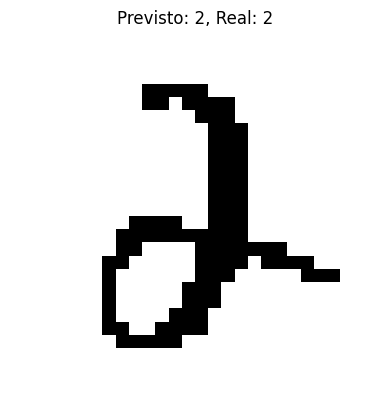

In [77]:
# INFERÊNCIA!!

index = 990     # Escolha um índice do Split de Teste para testar

# Realiza inferência em uma única imagem de teste. Chamamos o modelo diretamente que usa seu método __call__.
prediction = SimpleNN(x_test[index].to(device))    # Fazemos a inferência da imagem, Apenas Forward Pass.

print(f"O dígito previsto é: {prediction.item()}")    # Argmax nos retornou o índice do máximo

print(f"O rótulo real é: {y_test[index].item()}") # Exibe o rótulo real para comparação

# Remodela a imagem achatada de volta para 28x28 para visualização.
image = x_test[index].reshape(28, 28)  # Voltando a 28x28
plt.imshow(image, cmap='binary')
plt.title(f"Previsto: {prediction.item()}, Real: {y_test[index].item()}")
plt.axis('off')
plt.show()

O dígito previsto é: 7
O rótulo real é: 7


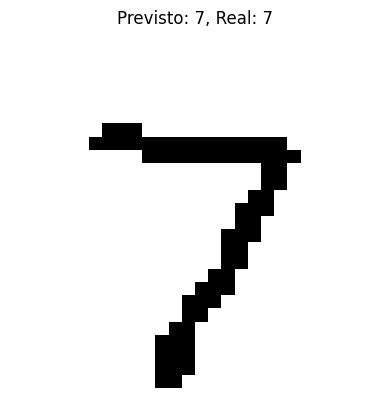

In [78]:
# INFERÊNCIA!!

index = 0     # Escolha um índice do Split de Teste para testar
prediction = SimpleNN(x_test[index].to(device))    # Fazemos a inferência da imagem, Apenas Forward Pass.
print(f"O dígito previsto é: {prediction.item()}")    # Argmax nos retornou o índice do máximo
print(f"O rótulo real é: {y_test[index].item()}") # Exibe o rótulo real para comparação

# Remodela a imagem achatada de volta para 28x28 para visualização.
image = x_test[index].reshape(28, 28)  # Voltando a 28x28
plt.imshow(image, cmap='binary')
plt.title(f"Previsto: {prediction.item()}, Real: {y_test[index].item()}")
plt.axis('off')
plt.show()

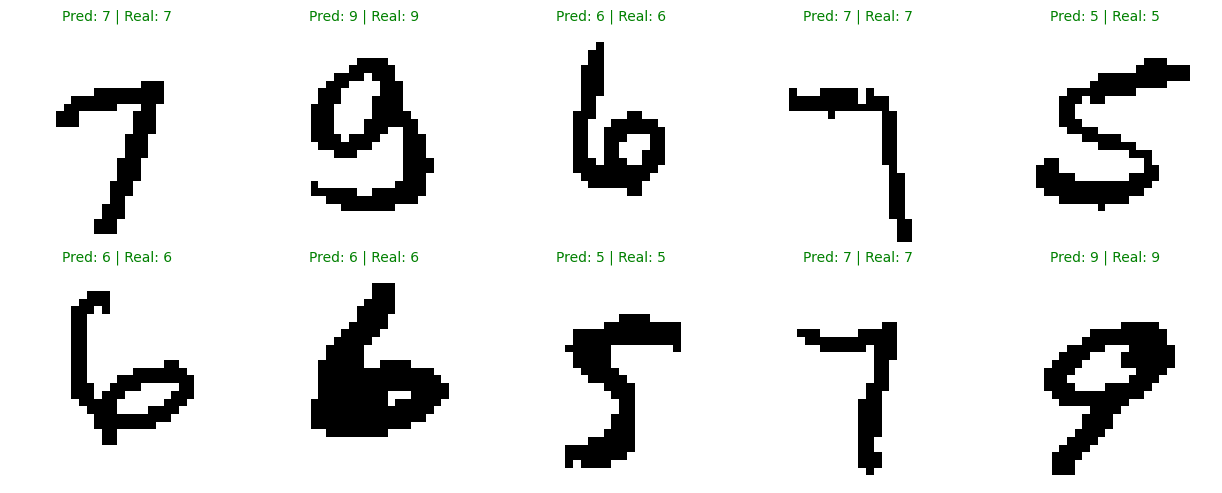

In [79]:
#@title
import matplotlib.pyplot as plt
import torch


def plot_random_predictions(
    model, x_test, y_test, num_samples=10, rows=2, cols=5, device="cpu"
):
    # Coloca o modelo em modo de avaliação e desativa os gradientes
    model.eval()

    # Seleciona índices aleatórios do conjunto de teste
    indices = torch.randperm(len(x_test))[:num_samples]

    plt.figure(figsize=(cols * 2.5, rows * 2.5))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Inferência no dispositivo configurado (CPU ou GPU)
            prediction = model(x_test[idx].to(device))

            # Garante que a imagem esteja na CPU para o matplotlib desenhar
            image = x_test[idx].cpu().reshape(28, 28)
            pred_label = prediction.item()
            real_label = y_test[idx].item()

            # Define a cor do título: verde se acertou, vermelho se errou
            color = "green" if pred_label == real_label else "red"

            plt.subplot(rows, cols, i + 1)
            plt.imshow(image, cmap="binary")
            plt.title(
                f"Pred: {pred_label} | Real: {real_label}",
                color=color,
                fontsize=10,
            )
            plt.axis("off")

    plt.tight_layout()
    plt.show()


# --- COMO USAR ---

# Para 10 dígitos aleatórios (layout 2x5):
plot_random_predictions(
    SimpleNN, x_test, y_test, num_samples=10, rows=2, cols=5, device=device
)

# Para preencher uma grade 5x5 completa (25 dígitos):
# plot_random_predictions(SimpleNN, x_test, y_test, num_samples=25, rows=5, cols=5, device=device)

Total de erros encontrados: 240 de 10000
Percentual de erros: 2.4%


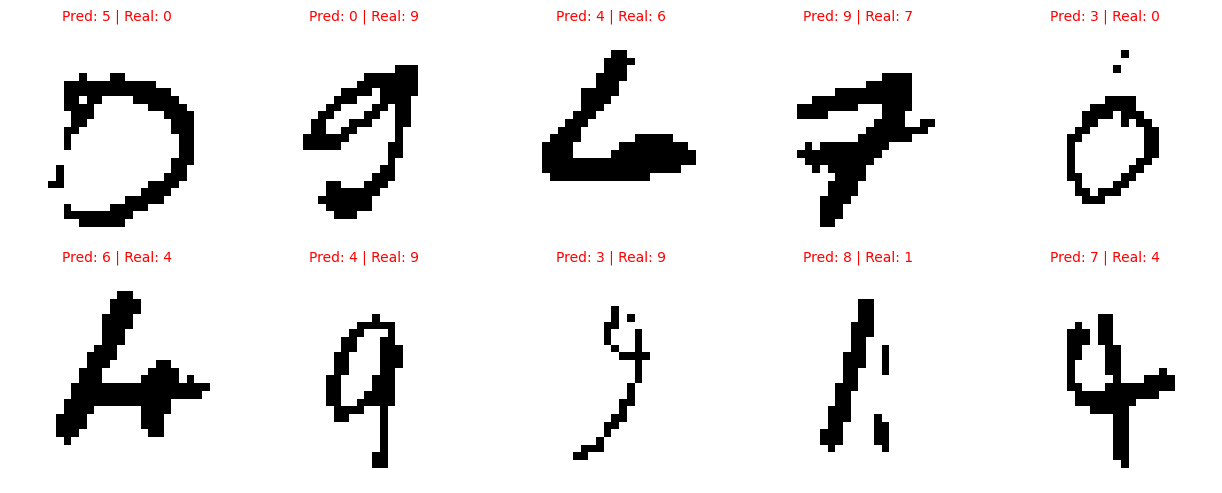

In [83]:
import matplotlib.pyplot as plt
import torch


def plot_misclassifications(
    model, x_test, y_test, num_samples=10, rows=2, cols=5, device="cpu"
):
    model.eval()
    misclassified_indices = []

    # 1. Identifica todos os índices onde a predição foi incorreta
    with torch.no_grad():
        for idx in range(len(x_test)):
            pred = model(x_test[idx].to(device)).item()
            real = y_test[idx].item()

            if pred != real:
                misclassified_indices.append(idx)

    # Trata o caso de o modelo não ter cometido erros
    if not misclassified_indices:
        print("Nenhum erro de classificação foi encontrado no conjunto de teste!")
        return

    print(f"Total de erros encontrados: {len(misclassified_indices)} de {len(x_test)}")
    print(f"Percentual de erros: {len(misclassified_indices)/len(x_test)*100.0}%")

    # 2. Seleciona aleatoriamente até `num_samples` entre os erros encontrados
    misclassified_indices = torch.tensor(misclassified_indices)
    sample_count = min(num_samples, len(misclassified_indices))
    selected_indices = misclassified_indices[
        torch.randperm(len(misclassified_indices))[:sample_count]
    ]

    # 3. Renderiza a grade com as falhas
    plt.figure(figsize=(cols * 2.5, rows * 2.5))

    with torch.no_grad():
        for i, idx in enumerate(selected_indices):
            idx = idx.item()
            pred_label = model(x_test[idx].to(device)).item()
            real_label = y_test[idx].item()
            image = x_test[idx].cpu().reshape(28, 28)

            plt.subplot(rows, cols, i + 1)
            plt.imshow(image, cmap="binary")
            plt.title(
                f"Pred: {pred_label} | Real: {real_label}",
                color="red",
                fontsize=10,
            )
            plt.axis("off")

    plt.tight_layout()
    plt.show()

# Exibe 10 imagens com erros de classificação (layout 2x5)
plot_misclassifications(
    SimpleNN, x_test, y_test, num_samples=10, rows=2, cols=5, device=device
)

# Para preencher uma grade 5x5 com 25 falhas:
# plot_misclassifications(SimpleNN, x_test, y_test, num_samples=25, rows=5, cols=5, device=device)

### 8. Salvando o Modelo

É uma boa prática salvar os pesos do modelo treinado. Isso nos permite carregar o modelo mais tarde sem retreiná-lo, para implantação ou avaliação futura. Salvamos o `state_dict()`, que contém todos os parâmetros treináveis do modelo.

In [80]:
# Salva os pesos (convencionalmente usando extensão .pt ou .pth)
torch.save(SimpleNN.state_dict(), "SimpleNN_export.pth")
print("Pesos do modelo salvos em SimpleNN_export.pth")

Pesos do modelo salvos em SimpleNN_export.pth
